### Breast Cancer Wisconsiny dataset - Decision Tree Classifier

#### Andres Cruz Chipol

A high-stakes binary medical classification problem aimed at
diagnosing tumors as benign or malignant.

url:https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic

###  Phase A: Data Preprocessing
Load the datasets into your chosen development environment (Python with scikit-learn or R with
rpart are highly recommended).
Handle missing values professionally using justified imputation or row-removal techniques.
Encode categorical variables appropriately (e.g., One-Hot Encoding or Label Encoding).
Split each dataset into a balanced Training Set and Testing Set.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

base_features = ['radius', 'texture', 'perimeter', 'area', 'smoothness',
                  'compactness', 'concavity', 'concave_points', 'symmetry', 'fractal_dimension']

feature_cols = [f"{feat}{suf}" for suf in ['1', '2', '3'] for feat in base_features]

column_names = ['ID', 'Diagnosis'] + feature_cols

print(f"Total de columnas: {len(column_names)}")
# Agregamos las columnas, ya que no las tiene,
dfWdbc = pd.read_csv("wdbc.data", header=None,names=column_names)

Total de columnas: 32


In [2]:
dfWdbc.head(10)
# Lo primero que notamos es que no hay nombres de columnas.

,ID,Diagnosis,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,...,radius3,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678
5,843786,M,12.45,15.70,82.57,477.1,0.12780,0.17000,0.15780,0.08089,...,15.47,23.75,103.40,741.6,0.1791,0.5249,0.5355,0.1741,0.3985,0.12440
6,844359,M,18.25,19.98,119.60,1040.0,0.09463,0.10900,0.11270,0.07400,...,22.88,27.66,153.20,1606.0,0.1442,0.2576,0.3784,0.1932,0.3063,0.08368
7,84458202,M,13.71,20.83,90.20,577.9,0.11890,0.16450,0.09366,0.05985,...,17.06,28.14,110.60,897.0,0.1654,0.3682,0.2678,0.1556,0.3196,0.11510
8,844981,M,13.00,21.82,87.50,519.8,0.12730,0.19320,0.18590,0.09353,...,15.49,30.73,106.20,739.3,0.1703,0.5401,0.5390,0.2060,0.4378,0.10720
9,84501001,M,12.46,24.04,83.97,475.9,0.11860,0.23960,0.22730,0.08543,...,15.09,40.68,97.65,711.4,0.1853,1.0580,1.1050,0.2210,0.4366,0.20750


In [3]:
dfWdbc.describe()

,ID,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,...,radius3,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [4]:
dfWdbc['Diagnosis'].value_counts()
# Se puede observar un pequeno desbalance en la cantidad de muestras de cada clase, pero no es tan grande como para que sea un problema. (Al menos en este momento)

Diagnosis
B    357
M    212
Name: count, dtype: int64

In [5]:
dfWdbc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  569 non-null    int64  
 1   Diagnosis           569 non-null    object 
 2   radius1             569 non-null    float64
 3   texture1            569 non-null    float64
 4   perimeter1          569 non-null    float64
 5   area1               569 non-null    float64
 6   smoothness1         569 non-null    float64
 7   compactness1        569 non-null    float64
 8   concavity1          569 non-null    float64
 9   concave_points1     569 non-null    float64
 10  symmetry1           569 non-null    float64
 11  fractal_dimension1  569 non-null    float64
 12  radius2             569 non-null    float64
 13  texture2            569 non-null    float64
 14  perimeter2          569 non-null    float64
 15  area2               569 non-null    float64
 16  smoothne

In [6]:
# El id no aporta nada, y mapearemos el diagnostico a 0 y 1 para poder usarlo en el modelo.
dfWdbc = dfWdbc.drop(columns=['ID'])
dfWdbc['Diagnosis'] = dfWdbc['Diagnosis'].map({'M': 1, 'B': 0})
dfWdbc.head()

,Diagnosis,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,...,radius3,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


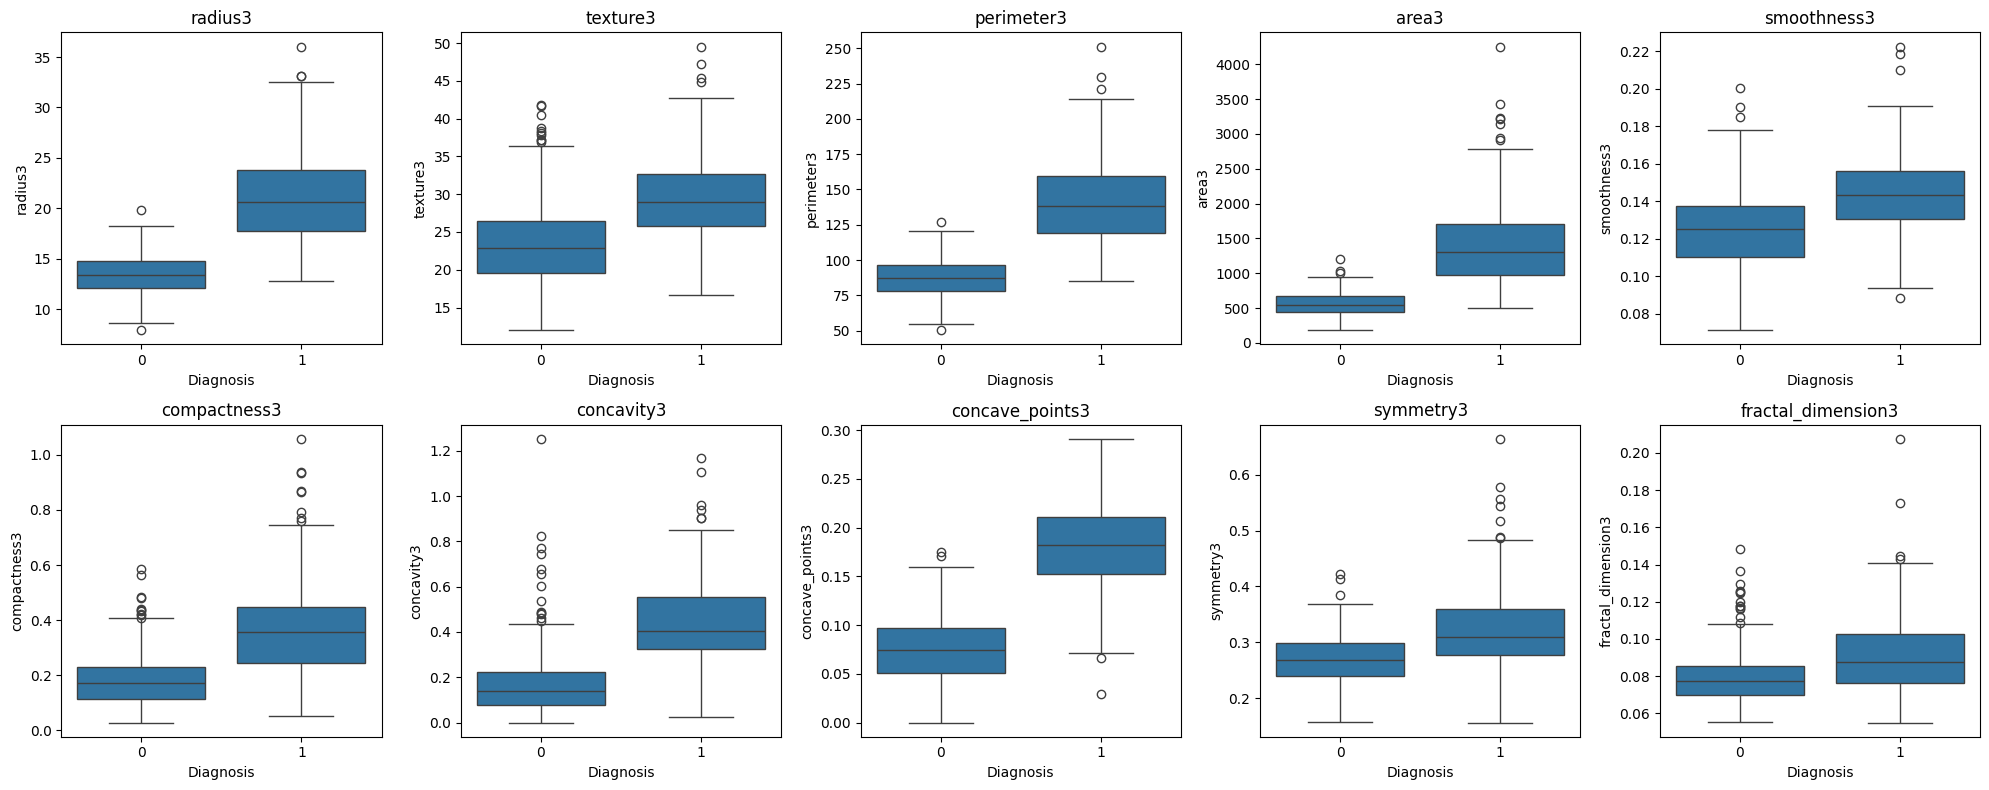

In [ ]:
worst_features = [c for c in dfWdbc.columns if c.endswith('3')]

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.ravel()

for i, col in enumerate(worst_features):
    sns.boxplot(data=dfWdbc, x='Diagnosis', y=col, ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()
# Podemos visualizar estos outliers, no los quitaremos pues estamos usando Decision Trees, que no se ven afectados por outliers. Pero si se quisiera usar otro modelo, sería recomendable quitarlos.

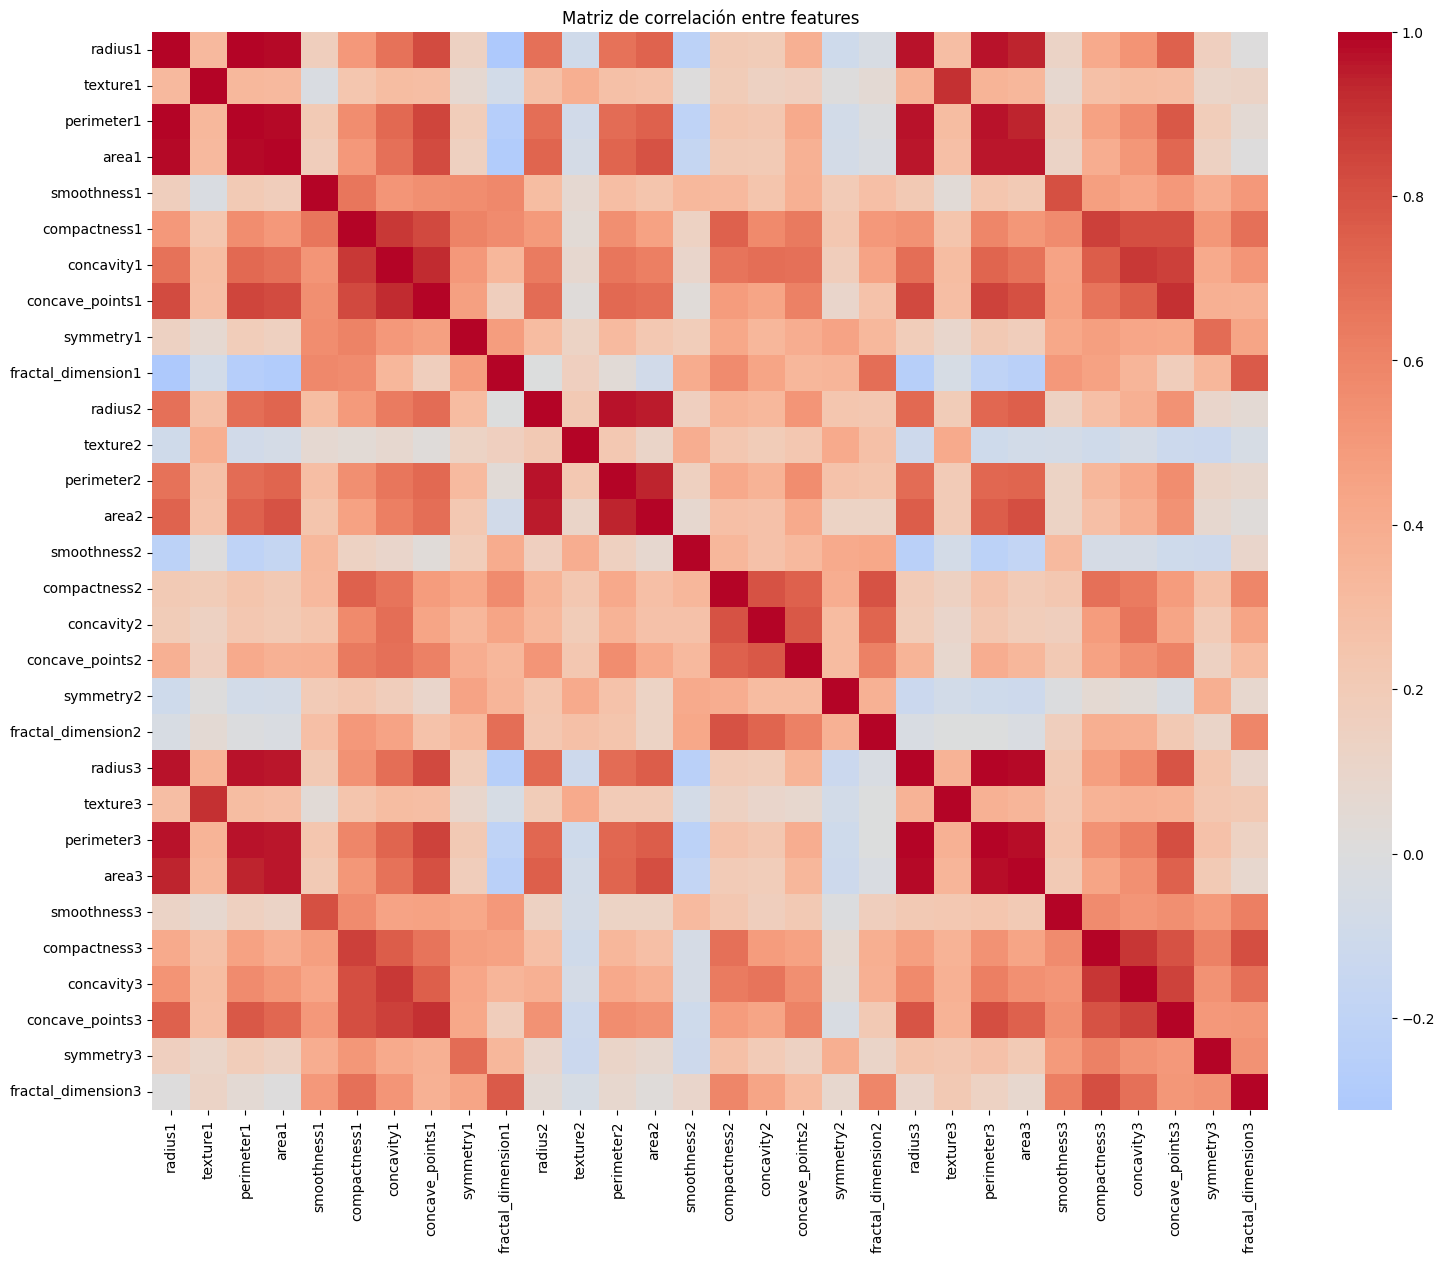

radius1          perimeter1         0.997855
perimeter3       radius3            0.993708
radius1          area1              0.987357
perimeter1       area1              0.986507
radius3          area3              0.984015
area3            perimeter3         0.977578
radius2          perimeter2         0.972794
perimeter1       perimeter3         0.970387
radius1          radius3            0.969539
perimeter1       radius3            0.969476
radius1          perimeter3         0.965137
radius3          area1              0.962746
area1            area3              0.959213
perimeter3       area1              0.959120
radius2          area2              0.951830
area3            perimeter1         0.941550
                 radius1            0.941082
perimeter2       area2              0.937655
concavity1       concave_points1    0.921391
texture1         texture3           0.912045
concave_points3  concave_points1    0.910155
dtype: float64


In [ ]:
plt.figure(figsize=(18, 14))
corr = dfWdbc[feature_cols].corr()
sns.heatmap(corr, cmap='coolwarm', center=0, annot=False)
plt.title('Matriz de correlación entre features')
plt.show()

# Pares de features con correlación muy alta (>0.9)
alta_corr = corr.abs().unstack().sort_values(ascending=False)
alta_corr = alta_corr[(alta_corr < 1.0) & (alta_corr > 0.9)]
print(alta_corr.drop_duplicates())
# Igual podemos ver como se correlacion algunas caracteristias de forma muy fuerte. De momento no haremos ningun cambio, pero si se quisiera usar un modelo lineal, sería recomendable quitar algunas de estas caracteristicas para evitar multicolinealidad.

In [10]:
# Es hora de guardar mi dataset limpio para usarlo en el modelo.
dfWdbc.to_csv("wdbc_cleaned.csv", index=False)

### Phase B: Model Building

Train a baseline Decision Tree classifier using the training partition.

Analyze the initial splitting criteria and structure generated by the algorithm. 

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [11]:
# Carga de datos
dfWdbc = pd.read_csv("wdbc_cleaned.csv")
X = dfWdbc.drop(columns=['Diagnosis'])
y = dfWdbc['Diagnosis']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

classifier = DecisionTreeClassifier(random_state=42, class_weight='balanced')
classifier.fit(X_train, y_train)

y_pred = classifier.predict(X_test)

In [12]:
# Vamos a analizar la estructura del árbol generado y la importancia de las variables para entender cómo el modelo está tomando decisiones.

# Extraemos métricas de la estructura del árbol
max_depth = classifier.tree_.max_depth
leaves = classifier.get_n_leaves()
total_nodes = classifier.tree_.node_count

print(f"Profundidad máxima del árbol: {max_depth}")
print(f"Número de nodos hoja (reglas finales): {leaves}")
print(f"Número total de nodos en el árbol: {total_nodes}")

# Un árbol con una profundidad de más de 40 niveles y miles de hojas
# está claramente memorizando el conjunto de entrenamiento (sobreajuste).

feature_names = X_train.columns

# Análisis del Nodo Raíz a bajo nivel (Initial Splitting Criteria)
internal_tree = classifier.tree_
root_node = 0

feature_idx = internal_tree.feature[root_node]
feature_name = feature_names[feature_idx]
threshold = internal_tree.threshold[root_node]
impurity = internal_tree.impurity[root_node]
samples = internal_tree.n_node_samples[root_node]

print("\nCriterio de División Inicial (Root Node)")
print(f"Característica seleccionada : {feature_name}")
print(f"Valor umbral (Threshold)    : <= {threshold:.4f}")
print(f"Impureza inicial (Gini)     : {impurity:.4f}")
print(f"Total de muestras evaluadas : {samples}")

Profundidad máxima del árbol: 7
Número de nodos hoja (reglas finales): 26
Número total de nodos en el árbol: 51

Criterio de División Inicial (Root Node)
Característica seleccionada : perimeter3
Valor umbral (Threshold)    : <= 112.8000
Impureza inicial (Gini)     : 0.5000
Total de muestras evaluadas : 455


|--- perimeter3 <= 112.80
|   |--- concave_points3 <= 0.14
|   |   |--- area1 <= 696.25
|   |   |   |--- truncated branch of depth 5
|   |   |--- area1 >  696.25
|   |   |   |--- truncated branch of depth 2
|   |--- concave_points3 >  0.14
|   |   |--- texture3 <= 25.67
|   |   |   |--- truncated branch of depth 4
|   |   |--- texture3 >  25.67
|   |   |   |--- truncated branch of depth 3
|--- perimeter3 >  112.80
|   |--- texture1 <= 14.95
|   |   |--- smoothness1 <= 0.11
|   |   |   |--- class: 0
|   |   |--- smoothness1 >  0.11
|   |   |   |--- class: 1
|   |--- texture1 >  14.95
|   |   |--- area3 <= 810.10
|   |   |   |--- truncated branch of depth 3
|   |   |--- area3 >  810.10
|   |   |   |--- truncated branch of depth 4



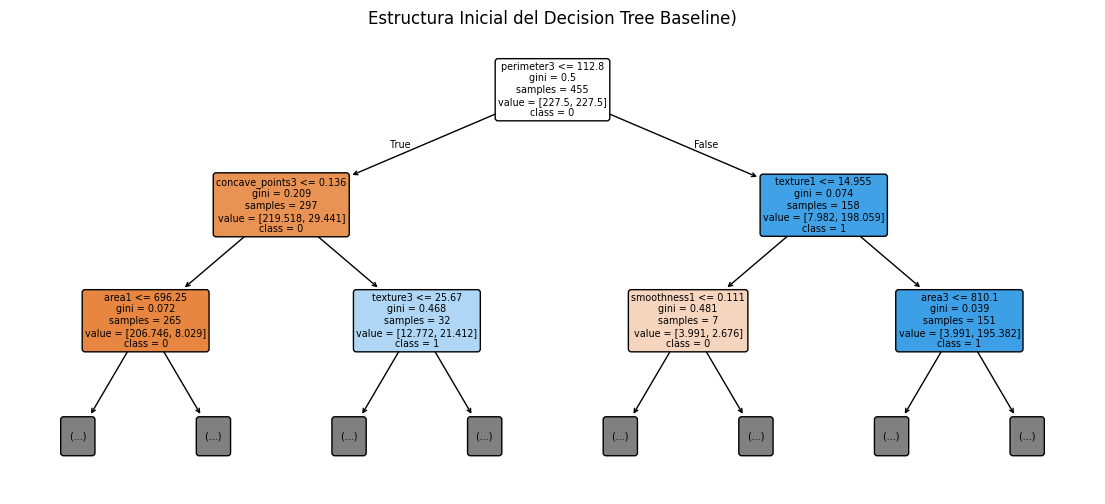

In [ ]:
tree_rules = export_text(classifier, feature_names=list(feature_names), max_depth=2)
print(tree_rules)

plt.figure(figsize=(14, 6))
plot_tree(classifier,
          feature_names=feature_names,
          class_names=['0', '1'],
          filled=True,
          rounded=True,
          max_depth=2)
plt.title("Estructura Inicial del Decision Tree Baseline)")
plt.show()
# Podemos visualizar que perimeter3, texture3 y concavity3 son las variables más importantes en la primera división del árbol, lo que indica que estas características tienen un gran impacto en la clasificación de los tumores como malignos o benignos.
# Ya que es una area que desconozco, no puedo dar una explicación biológica de por qué estas características son importantes, pero es un hallazgo interesante que podría ser explorado más a fondo.
# De momento vemos que el gini es de 0.5, lo que indica que el nodo raíz está bastante mezclado, y que la primera división del árbol es crucial para separar las clases de manera efectiva.
# para concave_points3, vemos que el umbral es 0.02, lo que significa que si un tumor tiene un valor de concave_points3 menor o igual a 0.02, se clasifica como benigno (0), mientras que si es mayor a 0.02, se clasifica como maligno (1). Esto sugiere que la presencia de puntos cóncavos en la superficie del tumor es un indicador importante de malignidad.

### Phase C: Model Evaluation

Rigorously evaluate model performance using standard classification metrics: Accuracy, Precision,

Recall, F1-Score, and the Confusion Matrix.

Apply the trained model to the testing set and explicitly compare predicted values against actual groundtruth values.

Identify and discuss signs of overfitting or underfitting based on training vs. test metrics.

In [ ]:
def evaluate_model(model, X_train, y_train, X_test, y_test, dataset_name):
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)

    print(f"{dataset_name}Performance -----------------------")
    print(f"Training Accuracy:  {train_acc:.4f}")
    print(f"Testing Accuracy:   {test_acc:.4f}")
    print(f"Generalization Gap: {(train_acc - test_acc):.4f}\n")
    print(f"Classification Report:\n{classification_report(y_test, y_test_pred)}")
    print(f"Confusion Matrix:\n{confusion_matrix(y_test, y_test_pred)}\n")

evaluate_model(classifier, X_train, y_train, X_test, y_test, "")
# Podemos visualizar como de buena forma el modelo no se sobreajusta tanto. su recall es muy bueno. indica que puede detectar correctamente la mayoría de los casos positivos (malignos) sin demasiados falsos negativos, lo cual es crucial en un contexto médico donde es preferible tener más falsos positivos que perder casos malignos.
# Esto es lo bueno de los Decision Trees, pueden servir con pocos datos y no se sobreajustan tanto como otros modelos más complejos.
# Creo que lo interesante estara en hacer el hiperparametro tuning, para ver si podemos mejorar el recall y la precision, y ver si podemos hacer un modelo más robusto, ya que siendo datos muy sensibles puede ser necesario tener un mejor modelo.

Performance -----------------------
Training Accuracy:  1.0000
Testing Accuracy:   0.9035
Generalization Gap: 0.0965

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.94      0.93        72
           1       0.90      0.83      0.86        42

    accuracy                           0.90       114
   macro avg       0.90      0.89      0.89       114
weighted avg       0.90      0.90      0.90       114

Confusion Matrix:
[[68  4]
 [ 7 35]]



### Phase D: Hyperparameter Tuning

Experiment with key tree hyperparameters (e.g., maximum depth max_depth, minimum samples required

to split a node min_samples_split, or impurity criteria: Gini vs. Entropy) to optimize classification

boundaries.


In [27]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.tree import DecisionTreeClassifier

param_distributions = {
    'criterion': ['gini', 'entropy', 'log_loss'],
    'max_depth': [3, 4, 5, 6, 7, 8, 10, 12, 15, 20, None],
    'min_samples_split': [2, 3, 4, 5, 8, 10, 15, 20, 30, 50],
    'min_samples_leaf': [1, 2, 3, 5, 8, 10, 15, 20, 30],
    'max_features': [None, 'sqrt', 'log2'],
    'class_weight': ['balanced', None],
    'splitter': ['best', 'random']
}

def optimize_and_evaluate(X_train, y_train, X_test, y_test, dataset_name, scoring='recall'):
    clf = DecisionTreeClassifier(random_state=42)

    random_search = RandomizedSearchCV(
        estimator=clf,
        param_distributions=param_distributions,
        n_iter=300,
        cv=5,
        scoring=scoring,
        random_state=42,
        n_jobs=-1
    )

    random_search.fit(X_train, y_train)
    best_model = random_search.best_estimator_

    y_train_pred = best_model.predict(X_train)
    y_test_pred = best_model.predict(X_test)

    print(f" Resultados para {dataset_name} (scoring='{scoring}')=")
    print("\nMejores hiperparámetros encontrados:")
    for param, value in random_search.best_params_.items():
        print(f" - {param}: {value}")

    print(f"\nAccuracy Entrenamiento: {accuracy_score(y_train, y_train_pred):.4f}")
    print(f"Accuracy en Prueba:     {accuracy_score(y_test, y_test_pred):.4f}")

    print("\nMatriz de confusión (test):")
    print(confusion_matrix(y_test, y_test_pred))

    print("\nClassification Report (test):\n",
          classification_report(y_test, y_test_pred, target_names=['Benigno (0)', 'Maligno (1)']))

    return best_model

In [28]:
modelo_recall = optimize_and_evaluate(X_train, y_train, X_test, y_test, "WDBC", scoring='recall')

 Resultados para WDBC (scoring='recall')=

Mejores hiperparámetros encontrados:
 - splitter: best
 - min_samples_split: 15
 - min_samples_leaf: 20
 - max_features: None
 - max_depth: 8
 - criterion: entropy
 - class_weight: balanced

Accuracy Entrenamiento: 0.9297
Accuracy en Prueba:     0.9386

Matriz de confusión (test):
[[68  4]
 [ 3 39]]

Classification Report (test):
               precision    recall  f1-score   support

 Benigno (0)       0.96      0.94      0.95        72
 Maligno (1)       0.91      0.93      0.92        42

    accuracy                           0.94       114
   macro avg       0.93      0.94      0.93       114
weighted avg       0.94      0.94      0.94       114



In [29]:
modelo_f1 = optimize_and_evaluate(X_train, y_train, X_test, y_test, "WDBC", scoring='f1')

 Resultados para WDBC (scoring='f1')=

Mejores hiperparámetros encontrados:
 - splitter: random
 - min_samples_split: 5
 - min_samples_leaf: 3
 - max_features: None
 - max_depth: 8
 - criterion: gini
 - class_weight: balanced

Accuracy Entrenamiento: 0.9692
Accuracy en Prueba:     0.9474

Matriz de confusión (test):
[[71  1]
 [ 5 37]]

Classification Report (test):
               precision    recall  f1-score   support

 Benigno (0)       0.93      0.99      0.96        72
 Maligno (1)       0.97      0.88      0.93        42

    accuracy                           0.95       114
   macro avg       0.95      0.93      0.94       114
weighted avg       0.95      0.95      0.95       114



In [ ]:
# En este caso optimizamos el modelo para maximizar el recall y el f1-score, que son métricas importantes en problemas de clasificación médica donde es crucial minimizar los falsos negativos (casos malignos no detectados).
# Nos quedamos con el recall por que es más importante en este caso, ya que queremos asegurarnos de detectar la mayor cantidad posible de casos malignos, incluso si eso significa tener algunos falsos positivos.

### Phase E: Interpretation & Insights

Graphically visualize the final decision tree structure (or a representative section if it is too dense) to understand the underlying logical rules.

Identify and report feature importance to determine which attributes carry the highest predictive power for each dataset.


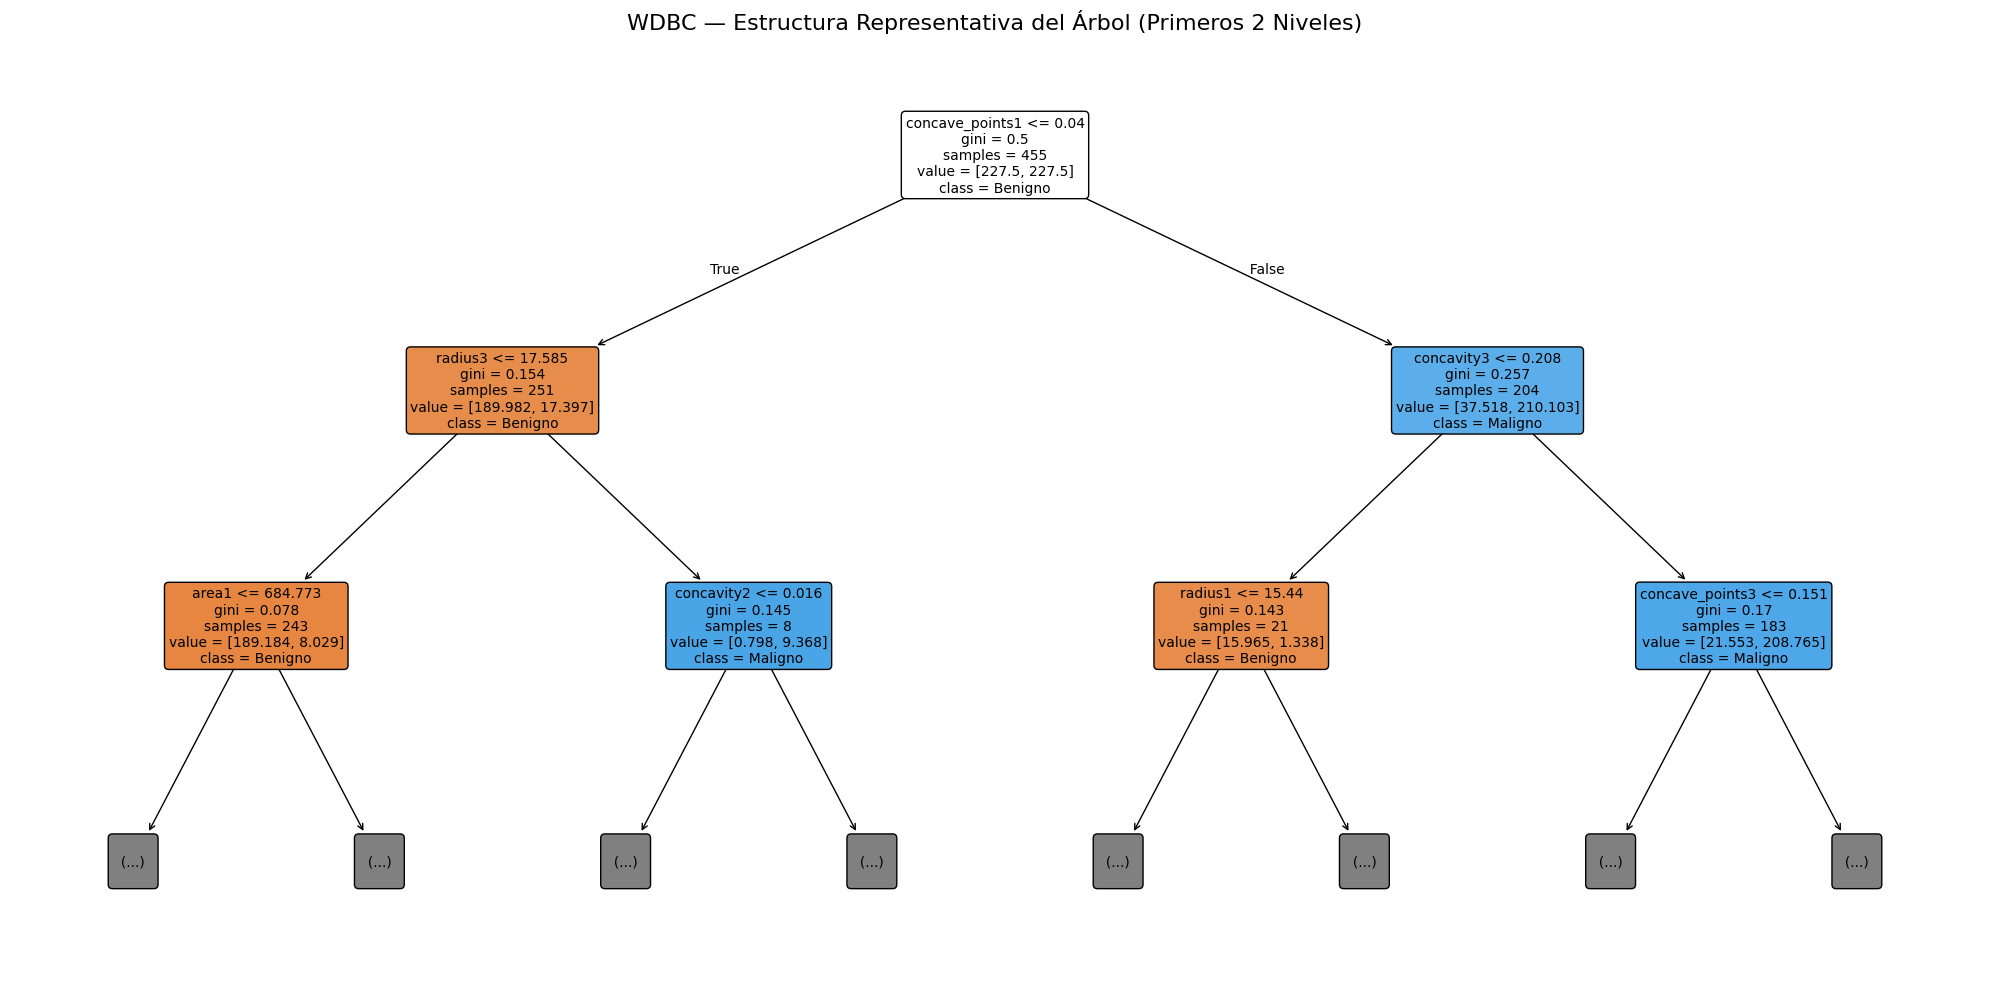

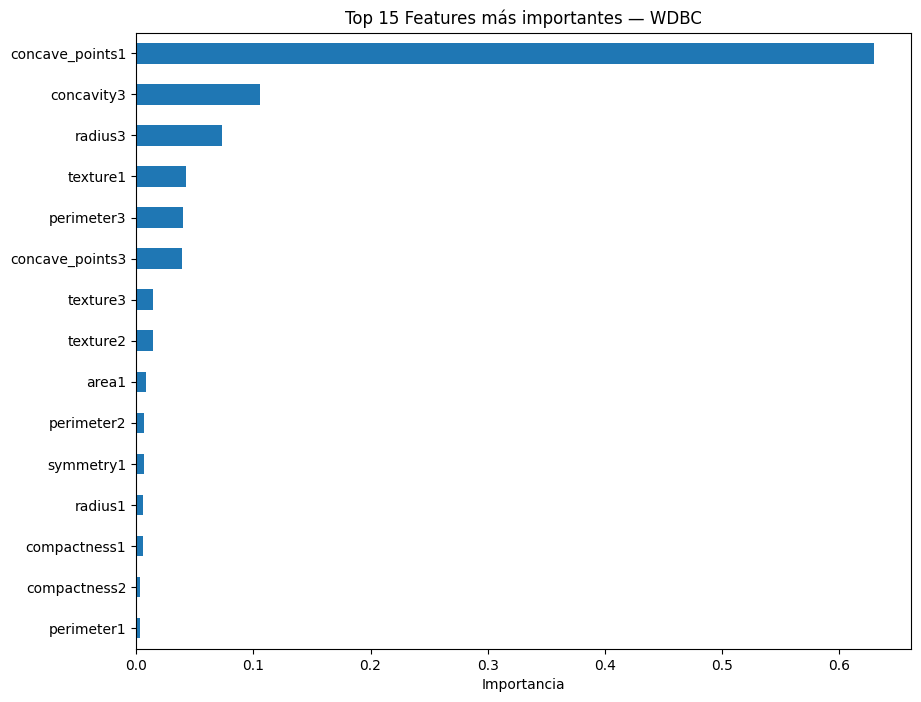

concave_points1    0.629657
concavity3         0.105516
radius3            0.073109
texture1           0.042758
perimeter3         0.040371
concave_points3    0.039269
texture3           0.014279
texture2           0.014121
area1              0.008563
perimeter2         0.007064
dtype: float64


In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
import pandas as pd

clases_diagnostico = ['Benigno', 'Maligno']

arbol_final = modelo_f1
fig, ax = plt.subplots(figsize=(20, 10))

plot_tree(arbol_final,
          max_depth=2,
          feature_names=X_train.columns,
          class_names=clases_diagnostico,
          filled=True,
          rounded=True,
          fontsize=10,
          ax=ax)
ax.set_title("WDBC — Estructura Representativa del Árbol (Primeros 2 Niveles)", fontsize=16)

plt.tight_layout()
plt.show()

importancias = pd.Series(arbol_final.feature_importances_, index=X_train.columns)
importancias = importancias[importancias > 0].sort_values(ascending=False)

plt.figure(figsize=(10, 8))
importancias.head(15).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title('Top 15 Features más importantes — WDBC')
plt.xlabel('Importancia')
plt.show()

print(importancias.head(10))
# Podemos visualizar que la raiz es concave_points1, con un gini de 0.5, lo que indica que el nodo raíz está bastante mezclado, y que la primera división del árbol es crucial para separar las clases de manera efectiva.
# Bajamos vemos como el radius3, concavity3, son las siguientes características más importantes, lo que sugiere que estas características son clave para la clasificación de tumores malignos y benignos en este dataset.
# para las caracterasticas mas importanes, vemos como concave_points es la mas dominante. Seguida de algunas pequenas destacas, que se van atenuando entre mas avanzan las caractersiticas.


In [31]:
# Por ultimo guardare el modelo entrenado en un archivo joblib para poder usarlo en un script de python y hacer predicciones sobre nuevos datos.
import joblib
joblib.dump(modelo_f1, 'wdbc_model.joblib', compress=3)

['wdbc_model.joblib']